# **UMAP in Python** 
 **Uniform Manifold Approximation and Projection for Dimensionality Reduction**

![image](https://umap-learn.readthedocs.io/en/latest/_images/plotting_21_2.png)
## **1. What is UMAP?**
### **What problem does UMAP solve?** 

In many design, sensing, and urban analysis projects, each observation is described by **many variables at once**.

For example, a single data point might include:
- multiple sensor readings (sound, temperature, humidity, heart rate)
- extracted features (energy, frequency, variation)
- metadata (time, location, category)

This means each observation lives in a **high-dimensional space** — not 2D or 3D, but 10, 20, or even hundreds of dimensions.

While computers can work in these spaces easily, **humans cannot**.

We can:
- look at one variable at a time
- compare two variables in a scatter plot
- occasionally inspect three variables in 3D

But beyond that, the structure of the data becomes hard to see.

The problem UMAP addresses is therefore **a problem of perception**:
- How can we *see* patterns in high-dimensional data?
- How can we understand similarity and difference across many variables at once?

UMAP solves this by **compressing high-dimensional data into 2D or 3D**, while trying to preserve:
- which points are close to each other
- which points are far apart

The result is not a literal representation of space, but a **map of relationships**.

In this map:
- nearby points behave similarly in the original data
- distant points behave differently

UMAP therefore turns abstract, high-dimensional measurements into a **spatial structure** that we can inspect, discuss, and work with.

This is why UMAP is useful in RC15: it allows complex datasets to be treated as **spatial material**, rather than as tables of numbers.

### **When is UMAP useful?**  

UMAP is useful when your data has **many variables** and you want to understand its **overall structure**, rather than inspecting individual values one by one.

A good example is the [**birdsong analysis by Lucio Arese**](https://www.youtube.com/watch?v=7lEiYqCV25s), where each short audio frame is described by many features at once:
- loudness and energy
- spectral properties (brightness, bandwidth)
- timbre descriptors (MFCCs and their variations)
- pitch and tonal information

Rather than analysing each feature separately, UMAP looks at **all features at once** and produces a 2D or 3D map where:
- similar sound events cluster together
- gradual changes appear as smooth transitions
- unusual sounds stand out as outliers

This makes UMAP particularly well suited for:
- audio and soundscape analysis
- sensor data with many correlated measurements
- feature sets that are difficult to interpret individually

In the birdsong example, UMAP does not tell us *what* a sound is, but it helps us see **how sounds relate to each other** as a spatial structure.


### **What UMAP is *not* (important limitations)**  

UMAP is a powerful tool, but it is important to be clear about **what it does not do**.

First, **UMAP is not a classifier**.  
It does not assign labels, categories, or meanings to data points.  
In the birdsong example, UMAP does not tell us which bird is singing or what type of call it is. It only shows which sounds are **similar or different** based on the features provided.

Second, **UMAP does not discover “ground truth” structure**.  
The patterns you see depend entirely on:
- the features you choose
- how those features are scaled
- the parameters you set

If you change the features or preprocessing, the map will change.

Third, **UMAP is not a physical or geographic space**.  
Distances in a UMAP plot do not correspond to real-world distances, time, or energy.  
In the birdsong example, nearby points do not mean sounds occurred close in time — only that they are similar in feature space.

Fourth, **UMAP is not fully deterministic** by default.  
Because it involves randomness, two runs with the same data can produce slightly different layouts unless a random seed is fixed.  
This means you should not over-interpret exact positions or orientations.

Fifth, **UMAP does not preserve all global structure**.  
It is very good at preserving local neighbourhoods, but large-scale distances and cluster spacing can be distorted.  
Clusters appearing far apart are not necessarily “more different” than others.

Finally, **UMAP is not an explanation**.  
It is a tool for exploration and intuition, not a final analytical result.  
UMAP helps you see patterns, but interpretation still requires domain knowledge and further analysis.

### **How does UMAP compare to other algorithms such as k-means, t-SNE, and PCA?**  
Several tools are often used with high-dimensional data, but they do **different things**.

**PCA** is a linear method.  
It reduces data by keeping directions with the most variation.  
In 2D or 3D, PCA often flattens complex patterns, but it is stable and easy to interpret.

**t-SNE** is a non-linear method focused on local similarity.  
In 2D, it separates clusters very clearly.  
In 3D, it rarely adds useful information.  
Distances between clusters should not be interpreted.

**UMAP** is also non-linear, but more flexible.  
In 2D, it gives readable neighbourhoods and clusters.  
In 3D, it can reveal smooth transitions and trajectories.  
UMAP is fast and can be reused to embed new data.

**k-means** is not a dimensionality-reduction method.  
It groups data into clusters but does not create a spatial map.  
2D or 3D views are only used to display the clusters.

### Quick summary

| Method | What it does | 2D / 3D behaviour |
|------|--------------|------------------|
| PCA | Linear reduction | Stable but often flat |
| t-SNE | Non-linear reduction | Clear clusters, weak global structure |
| UMAP | Non-linear reduction | Good balance; 3D can add insight |
| k-means | Clustering | No embedding, only labels |

For RC15, **UMAP is often the best starting point** because it turns complex data into a space that can be explored, mapped, and reused.


---

## **2.How to use this notebook**

This notebook is meant to be read [**alongside the official UMAP documentation**](https://umap-learn.readthedocs.io/en/latest/index.html).

It summarises and explains key ideas and techniques that are closer to **RC15 workflows**. Work through the notebook in order, run the code cells, and focus on the visual results.

If your goal is to **get started with UMAP**, this notebook is enough. If you want a **deeper understanding**, read this notebook and the official documentation in parallel.

--- 



## **3.Installation and setup**

### **Python environment requirements**

This notebook requires a **standard CPython environment**  It will **not run in IronPython** (legacy Grasshopper), because UMAP and several visualisation libraries rely on compiled packages.

A stable Python version is recommended: **Python 3.10 – 3.12**.


### **Required libraries**

This notebook uses the following libraries:

- `numpy` – numerical computation  
- `pandas` – tabular data handling  
- `scikit-learn` – preprocessing and utilities  
- `umap-learn` – UMAP implementation  

- `matplotlib` – basic 2D and 3D plotting  
- `seaborn` – exploratory statistical plots  
- `datashader` – raster-based density and connectivity visualisation  
- `bokeh` – interactive plotting backend  
- `holoviews` – high-level interface for Bokeh and Datashader  

You can install everything with:

```bash
pip install numpy pandas scikit-learn umap-learn matplotlib seaborn datashader bokeh holoviews
```
--- 



## **4.Worked example: Penguins dataset**

In this section we introduce a small, well-known dataset that is useful for learning dimensionality reduction.

We will use the **Palmer Penguins** dataset, which contains physical measurements of penguins from different species.  
Although the dataset is simple, it has enough variables to demonstrate why UMAP is useful.

### **4.1 Import libraries**

We start by importing the libraries needed for data handling and basic visualisation. 

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

"""
%matplotlib` inline is a Jupyter magic command that tells 
matplotlib to render plots directly inside the notebook output cells (instead of opening separate windows). 
It works with matplotlib-based plots (including seaborn) so figures show up just below the code that creates them. 
"""

'\n%matplotlib` inline is a Jupyter magic command that tells \nmatplotlib to render plots directly inside the notebook output cells (instead of opening separate windows). \nIt works with matplotlib-based plots (including seaborn) so figures show up just below the code that creates them. \n'

In [2]:
# Set the graphic style for seaborn
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

###  **4.1 What the data contains**  

In [3]:
penguins = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


The dataset includes measurements for individual penguins, such as:

- bill length and bill depth  
- flipper length  
- body mass  
- species and sex  

Each row represents one penguin, and each column represents one measured attribute.

As you can see, some rows contain `NaN`, which means that data is missing.  
These entries need to be either removed or replaced.

In this example, we remove the rows with missing values:


In [4]:
penguins = penguins.dropna()
# Check the distribution of species in the dataset
penguins.species.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [5]:
# Inspect the cleaned dataset
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


### **4.2 Basic inspection and plotting**

The code below creates a pairplot visualization from the seaborn library. Here's what each part does:

`sns.pairplot()` — Creates a grid of scatter plots showing relationships between every pair of numerical variables in your dataset

`penguins.drop("year", axis=1)` — Removes the "year" column from the penguins dataframe before plotting (since it's not needed for this analysis)

`hue='species'` — Colors each data point by penguin species, so you can visually distinguish between the three species (Adelie, Chinstrap, Gentoo) with different colors

`;` (semicolon) — Suppresses the output text that would normally print after executing the cell

You get a visual matrix showing how different penguin measurements (bill length, bill depth, flipper length, body mass, etc.) relate to each other, with each species shown in a different color. This makes it easy to spot patterns and see how the species differ across multiple dimensions simultaneously.

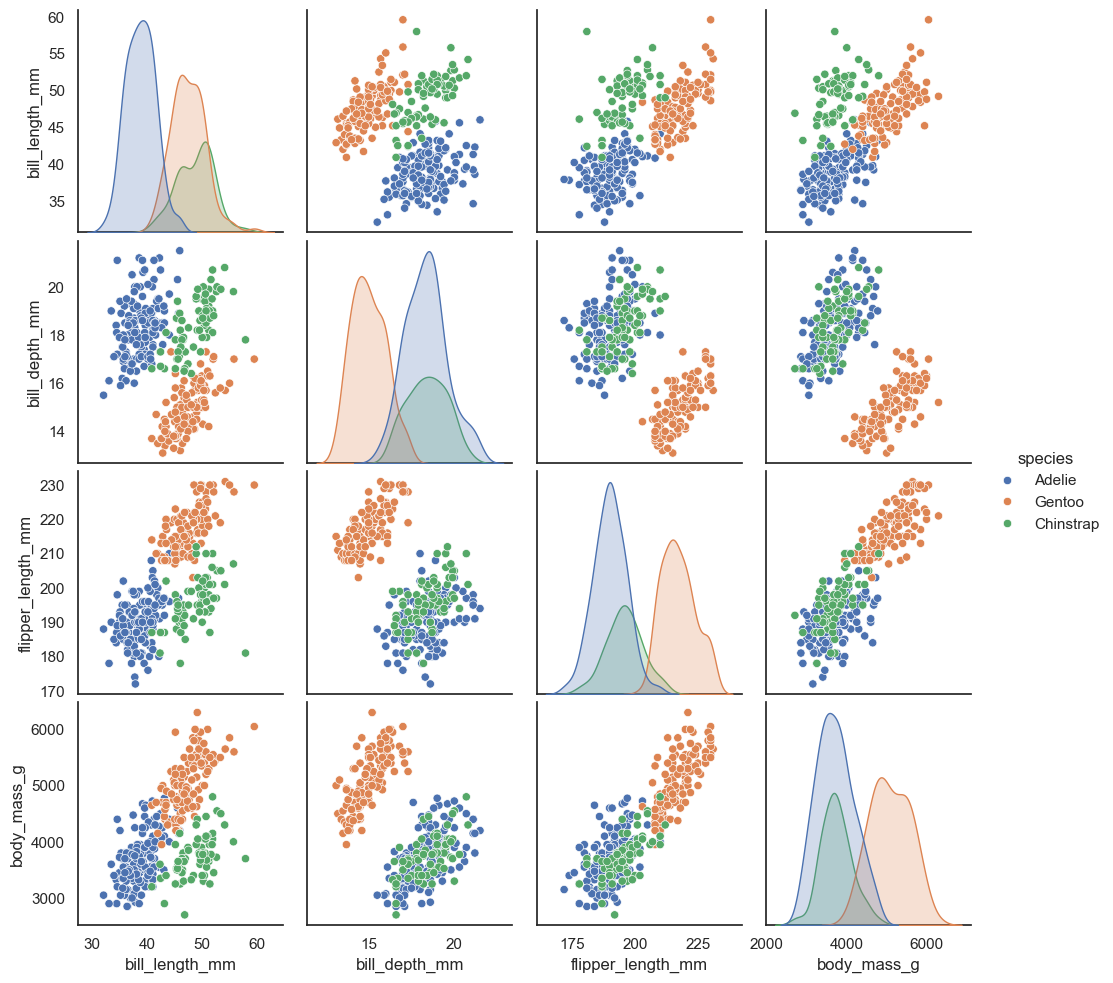

In [6]:
sns.pairplot(penguins.drop("year", axis=1), hue='species');

### **4.3 Normalise the data**

#### **Why scaling matters**

UMAP works by comparing points using **distance**.  This means that the numerical scale of each feature directly affects the result.

In the penguins dataset, different features use very different units:
- bill length and depth are measured in millimetres
- flipper length is measured in millimetres
- body mass is measured in grams

Because body mass has much larger numeric values, it would dominate the distance calculations if we used the raw data.

As a result, UMAP would mainly organise points by body mass, and other features would have much less influence.

To avoid this, we **normalise** the data before applying UMAP.

Normalisation rescales all features so that:
- they are comparable to each other
- no single measurement dominates because of its unit
- distances reflect overall similarity, not raw magnitude

After standardisation, all features are on a similar scale, which allows UMAP to work as intended.

#### **Standardisation using `StandardScaler`**

To standardise the numeric features, we use `StandardScaler` from `scikit-learn`.

`StandardScaler` transforms each feature so that:
- the mean becomes 0
- the standard deviation becomes 1 (these contain about 66% of all values)
- the range is about from -3 to 3

![image](https://www.sixsigmadaily.com/wp-content/uploads/sites/4/2012/08/Bell-Curve-Standard-Deviation.jpg)

This process is also known as **z-score standardisation**.

In practice, this means that:
- all features are placed on a comparable scale
- differences in units (millimetres, grams) no longer matter
- distance-based methods like UMAP behave more reliably

We apply standardisation only to the **numeric columns**, not to categorical data such as species or sex.

The code below selects the numeric features and applies the transformation:


In [7]:
# Select numerical features for analysis and convert to NumPy array for processing with scikit-learn
penguin_data = penguins[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
    ]
].values

# Scale features so that each column contributes comparably to distance calculations
scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

print("Scaled data shape:", scaled_penguin_data.shape)
scaled_penguin_data[:5]

Scaled data shape: (333, 4)


array([[-0.89604189,  0.7807321 , -1.42675157, -0.56847478],
       [-0.82278787,  0.11958397, -1.06947358, -0.50628618],
       [-0.67627982,  0.42472926, -0.42637319, -1.1903608 ],
       [-1.33556603,  1.0858774 , -0.56928439, -0.94160639],
       [-0.85941488,  1.74702554, -0.78365118, -0.69285199]])

### **4.4 New distribution curves**

This step is optional.  It shows how the transformed data actually looks after standardisation:

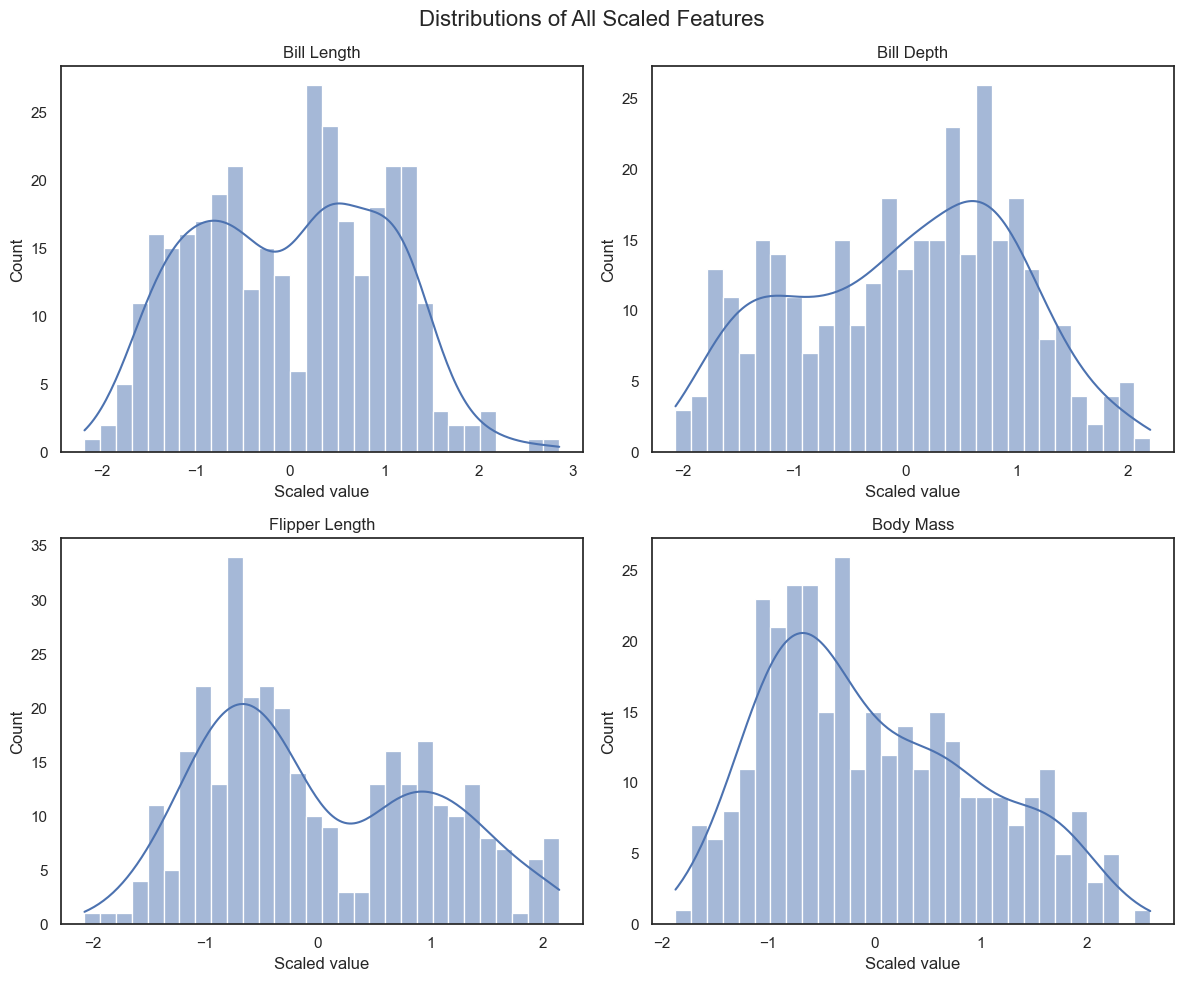

In [8]:
# Extract the first value (first feature) from each datapoint
first_feature_list = scaled_penguin_data[:, 0].tolist()
second_feature_list = scaled_penguin_data[:, 1].tolist()
third_feature_list = scaled_penguin_data[:, 2].tolist()
fourth_feature_list = scaled_penguin_data[:, 3].tolist()

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Distributions of All Scaled Features", fontsize=16)

# Plot 1: Bill Length
sns.histplot(first_feature_list, kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Bill Length")
axes[0, 0].set_xlabel("Scaled value")

# Plot 2: Bill Depth
sns.histplot(second_feature_list, kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Bill Depth")
axes[0, 1].set_xlabel("Scaled value")

# Plot 3: Flipper Length
sns.histplot(third_feature_list, kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Flipper Length")
axes[1, 0].set_xlabel("Scaled value")

# Plot 4: Body Mass
sns.histplot(fourth_feature_list, kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Body Mass")
axes[1, 1].set_xlabel("Scaled value")

plt.tight_layout()
plt.show()

### **4.5 Apply UMAP**


After normalising the data, we can now apply UMAP. UMAP takes the high-dimensional feature space (many measurements per penguin) and projects it into a lower-dimensional space that we can visualise and work with.

In this notebook, we reduce the data to **2D** and **3D**.

We start by imprting the library...


In [9]:
import umap

#### **Reducing to 2D**  

In 2D, each penguin becomes a point on a plane.  Penguins that are similar across all measured features appear close together, while different ones appear farther apart.

In [10]:
# Choose embedding dimension: 2 or 3
dim = 2  # change to 3 for 3D

# 1) Create the UMAP reducer (set parameters here)
reducer2D = umap.UMAP(
    n_components=dim,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# 2) FIT: learn the neighbour graph + embedding model from the training data
reducer2D.fit(scaled_penguin_data)

# 3) TRANSFORM: generate embedding coordinates
embedding2D = reducer2D.transform(scaled_penguin_data)

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



**Explanation of the UMAP steps (fit + transform)**

*Step 0 — Choose the embedding dimension*

```python
dim = 2  # change to 3 for 3D
````

This sets how many coordinates UMAP will output per point.

* `dim = 2` → each penguin becomes a point with (x, y)
* `dim = 3` → each penguin becomes a point with (x, y, z)


*Step 1 — Create the UMAP reducer*

```python
reducer2D = umap.UMAP(
    n_components=dim,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
```

This creates a UMAP object and sets its main parameters.
* `n_components=dim`→ The output dimension (2D or 3D).
* `n_neighbors=15`→ How many neighbours each point considers when UMAP builds its internal neighbour graph. Smaller values focus more on local structure; larger values include more global structure.
* `min_dist=0.1`→ How tightly points are allowed to pack together in the embedding. Smaller values create tighter clusters; larger values spread points out more.
* `metric="euclidean"`→ The distance function used in the original feature space.
* `random_state=42`→ Fixes randomness so you get repeatable results when re-running the notebook.



*Step 2 — Fit the model (learn structure from the data)*

```python
reducer2D.fit(scaled_penguin_data)
```

`fit()` means: learn the structure of the dataset.

UMAP does two main things here:

* it finds nearest neighbours for each point (based on the chosen metric)
* it builds a weighted neighbour graph that represents local relationships

At this stage, UMAP has learned how the points relate to each other, but it has not yet returned the final coordinates.

*Step 3 — Transform the data (produce the embedding coordinates)*

`embedding2D = reducer2D.transform(scaled_penguin_data)`

`transform()` means: generate the low-dimensional coordinates.The output `embedding2D` is an array where each row corresponds to one penguin.


#### **Reducing to 3D**  

In 3D, each penguin becomes a point in space.

In [11]:
# Choose embedding dimension: 2 or 3
dim3 = 3  # change to 3 for 3D

# 1) Create the UMAP reducer (set parameters here)
reducer3D = umap.UMAP(
    n_components=dim3,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# 2) FIT: learn the neighbour graph + embedding model from the training data
reducer3D.fit(scaled_penguin_data)

# 3) TRANSFORM: generate embedding coordinates
embedding3D = reducer3D.transform(scaled_penguin_data)

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 4.6 Visualise the results

There are two main ways to visualise the results.  
UMAP comes with its own plotting utilities (2D), or you can use libraries such as seaborn (2D and 3D).


In [12]:
import umap.plot

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compil

**Scatter plot (2D)**  

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

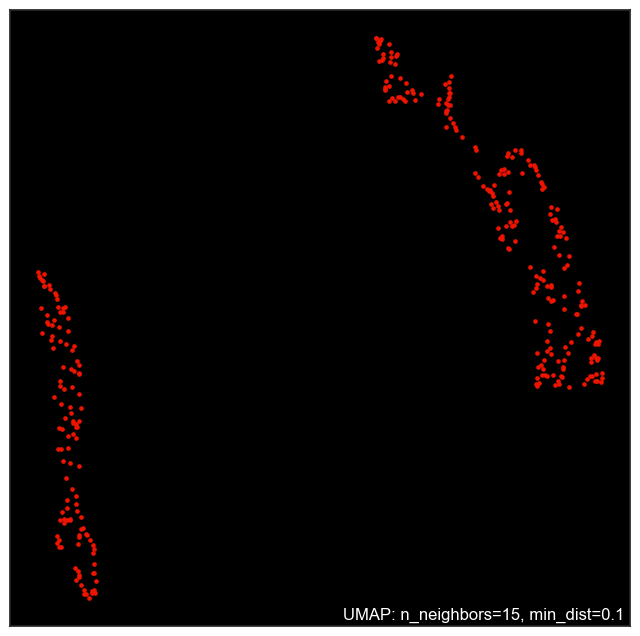

In [13]:
umap.plot.points(reducer2D.fit(scaled_penguin_data), theme='fire')

in alternative:

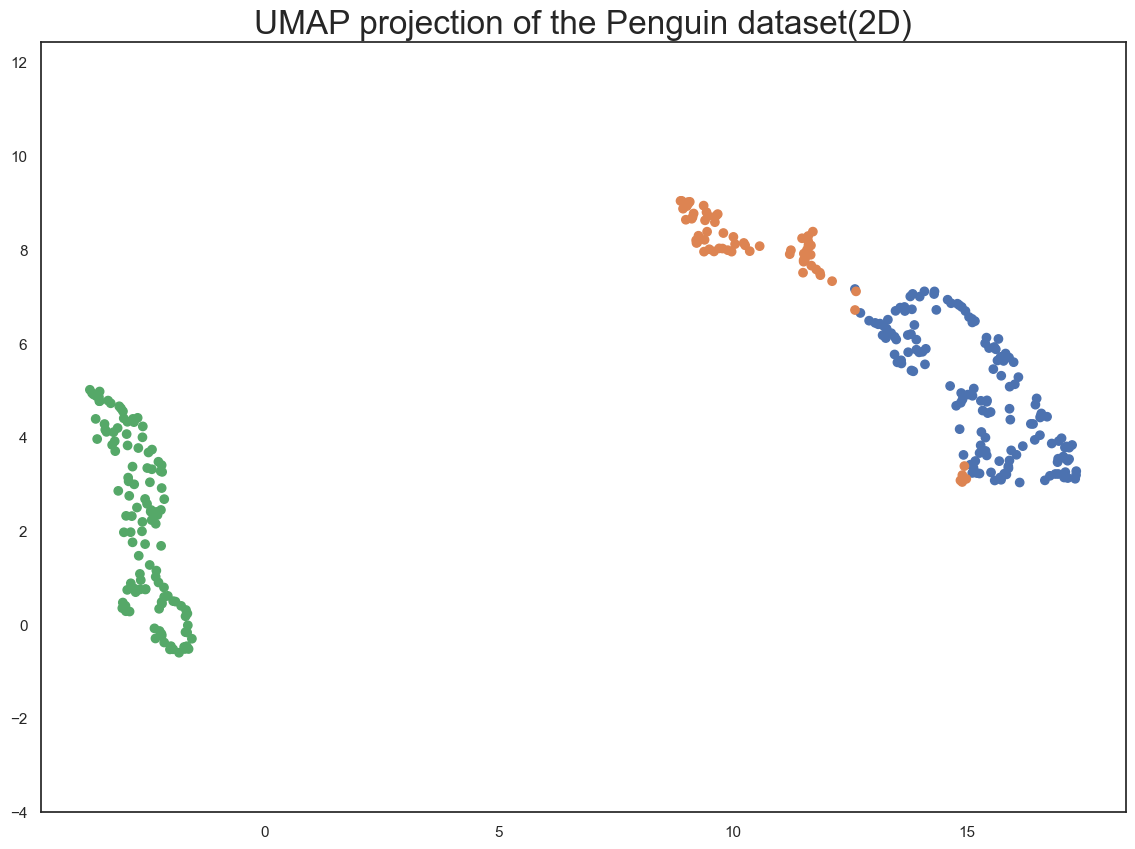

In [14]:
plt.scatter(
    embedding2D[:, 0],
    embedding2D[:, 1],
    c=[sns.color_palette()[x] for x in penguins.species.map({"Adelie":0, "Chinstrap":1, "Gentoo":2})])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the Penguin dataset(2D)', fontsize=24);

**Scatter plot (3D)**  

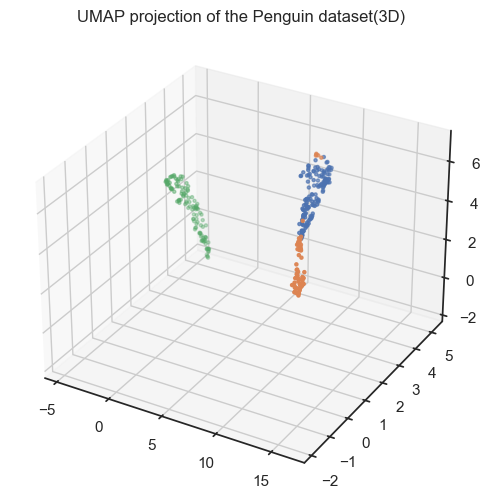

In [15]:
# Simple 3D plot (matplotlib)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedding3D[:, 0], embedding3D[:, 1], embedding3D[:, 2], c=[sns.color_palette()[x] for x in penguins.species.map({"Adelie":0, "Chinstrap":1, "Gentoo":2})], s=5)
ax.set_title("UMAP projection of the Penguin dataset(3D)")
plt.show()

### **4.7 Connectivity lines**

UMAP builds an internal **neighbour graph** before creating the final embedding.  
Connectivity lines visualise this graph by drawing links between nearby points.

<Axes: >

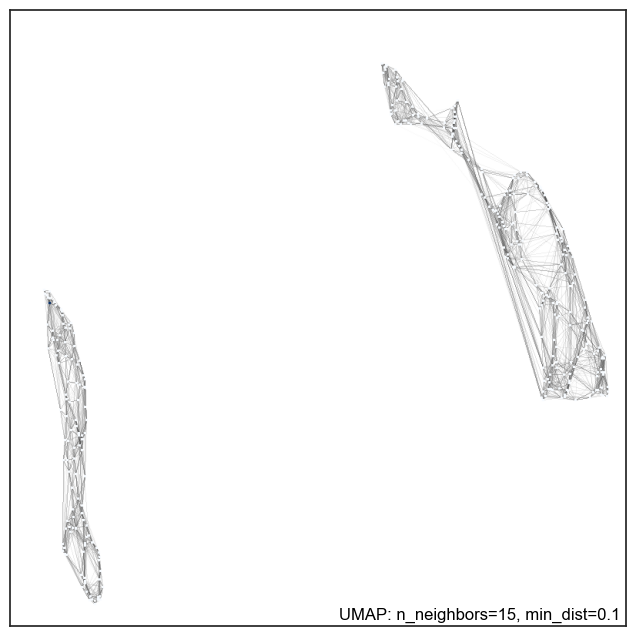

In [16]:
umap.plot.connectivity(reducer2D.fit(scaled_penguin_data), show_points=True)

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\plot.py:895: UserWarning: Hammer edge bundling is expensive for large graphs!
This may take a long time to compute!
  warn(


<Axes: >

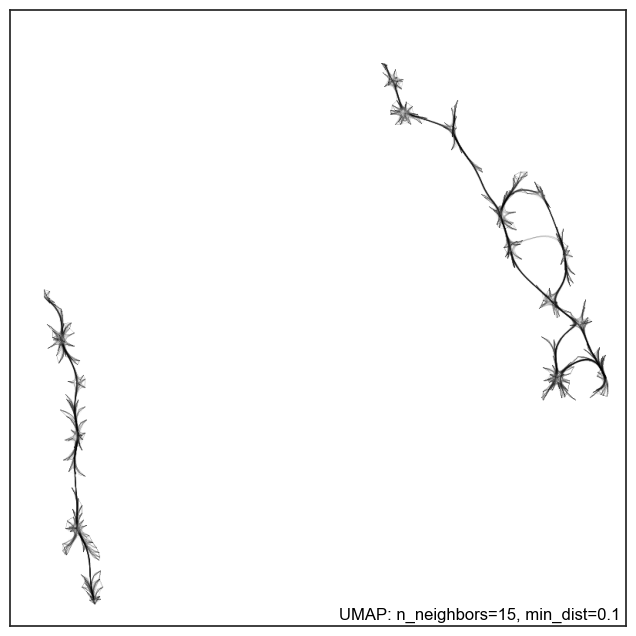

In [17]:
umap.plot.connectivity(reducer2D.fit(scaled_penguin_data), edge_bundling='hammer')

The example above is a **2D raster graphic**.  You can export the image itself, but not the individual lines as vector geometry.

Only the straight connectivity lines (without bundling) can be exported as vectors. Bundled connectivity and Datashader density maps are raster-based visualisations.


### **4.8 Export results**
**Export UMAP coordinates as CSV**  

In [18]:
# Export embeddings
import pandas as pd

out_2d = pd.DataFrame({
    "x": embedding2D[:, 0],
    "y": embedding2D[:, 1],
})

out_3d = pd.DataFrame({
    "x": embedding3D[:, 0],
    "y": embedding3D[:, 1],
    "z": embedding3D[:, 2],
})

out_2d_path = "umap_digits_2d.csv"
out_3d_path = "umap_digits_3d.csv"
out_2d.to_csv(out_2d_path, index=False)
out_3d.to_csv(out_3d_path, index=False)

print("Wrote:", out_2d_path)
print("Wrote:", out_3d_path)

Wrote: umap_digits_2d.csv
Wrote: umap_digits_3d.csv


**Export connectivity lines as CSV**

Extract the edges from the UMAP graph and save them with their coordinates (start and end points) for both 2D and 3D embeddings.

In [19]:
from scipy.sparse import coo_matrix
import pandas as pd

# Extract connectivity edges from 2D reducer
graph_2d = coo_matrix(reducer2D.graph_)
edges_2d = []

for i, j, v in zip(graph_2d.row, graph_2d.col, graph_2d.data):
    edges_2d.append({
        "source_idx": i,
        "target_idx": j,
        "source_x": embedding2D[i, 0],
        "source_y": embedding2D[i, 1],
        "target_x": embedding2D[j, 0],
        "target_y": embedding2D[j, 1],
        "weight": v
    })

edges_2d_df = pd.DataFrame(edges_2d)
edges_2d_path = "umap_connectivity_2d.csv"
edges_2d_df.to_csv(edges_2d_path, index=False)
print(f"Wrote {len(edges_2d_df)} edges to: {edges_2d_path}")

# Extract connectivity edges from 3D reducer
graph_3d = coo_matrix(reducer3D.graph_)
edges_3d = []

for i, j, v in zip(graph_3d.row, graph_3d.col, graph_3d.data):
    edges_3d.append({
        "source_idx": i,
        "target_idx": j,
        "source_x": embedding3D[i, 0],
        "source_y": embedding3D[i, 1],
        "source_z": embedding3D[i, 2],
        "target_x": embedding3D[j, 0],
        "target_y": embedding3D[j, 1],
        "target_z": embedding3D[j, 2],
        "weight": v
    })

edges_3d_df = pd.DataFrame(edges_3d)
edges_3d_path = "umap_connectivity_3d.csv"
edges_3d_df.to_csv(edges_3d_path, index=False)
print(f"Wrote {len(edges_3d_df)} edges to: {edges_3d_path}")

# Show sample of the data
print("\n2D Connectivity Sample:")
print(edges_2d_df.head())
print("\n3D Connectivity Sample:")
print(edges_3d_df.head())

Wrote 6062 edges to: umap_connectivity_2d.csv
Wrote 6062 edges to: umap_connectivity_3d.csv

2D Connectivity Sample:
   source_idx  target_idx   source_x  source_y   target_x  target_y    weight
0           0           5  15.115076  4.880742  15.305141  4.107536  0.332524
1           0          15  15.115076  4.880742  15.440327  4.510715  0.236301
2           0          16  15.115076  4.880742  15.425052  4.782604  1.000000
3           0          18  15.115076  4.880742  15.294312  4.773344  0.351136
4           0          21  15.115076  4.880742  14.901718  4.802652  0.562206

3D Connectivity Sample:
   source_idx  target_idx   source_x  source_y  source_z   target_x  target_y  \
0           0           5  10.875112  2.974778  5.977921  10.199663  3.275189   
1           0          15  10.875112  2.974778  5.977921  10.605002  3.309000   
2           0          16  10.875112  2.974778  5.977921  10.691866  3.164348   
3           0          18  10.875112  2.974778  5.977921  10.47156